In [1]:
# ============================================================
# THESIS: Privacy-Utility Trade-off in Churn Prediction
# Setup


from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    brier_score_loss,
    precision_score,
    recall_score,
    average_precision_score,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.base import clone
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

DATA_PATH = Path("Baza customer Telecom v2(1).csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Place 'Baza customer Telecom v2(1).csv' in the same folder as the notebook."
    )

OUTPUT_DIR = Path.cwd()

def out(filename: str) -> Path:
    return OUTPUT_DIR / filename

RANDOM_STATE = 42
TEST_SIZE = 0.20
TOP_K = 0.20
DP_EPSILON_VALUES = [0.5, 1.0, 5.0, 10.0]

print(f"Data path: {DATA_PATH.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Data path: /Users/dimitaraleksiev/Untitled Folder 1/Thesis_code_Dimitar/Baza customer Telecom v2(1).csv
Output directory: /Users/dimitaraleksiev/Untitled Folder 1/Thesis_code_Dimitar


**Data Loading and pre-processing**

In [2]:

#loading data

df = pd.read_csv(DATA_PATH, encoding="utf-8", sep=None, engine="python")
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")


df = df.drop(columns=["PID"])

df["CRM_PID_Value_Segment"] = df["CRM_PID_Value_Segment"].replace("Sliver", "Silver")


df["CHURN"] = (df["CHURN"] == "Yes").astype(int)
print(f"Churn rate: {df['CHURN'].mean():.4f} ({df['CHURN'].sum()} churners)")


#handle missing values

df = df.drop(columns=["Suspended_subscribers"])

df["Not_Active_subscribers"] = df["Not_Active_subscribers"].fillna(0)

mask = df["ARPU"].isnull()
df.loc[mask, "ARPU"] = df.loc[mask, "TotalRevenue"] / df.loc[mask, "Total_SUBs"]

df["Billing_ZIP"] = df["Billing_ZIP"].fillna(df["Billing_ZIP"].mode()[0])

df["CRM_PID_Value_Segment"] = df["CRM_PID_Value_Segment"].fillna(df["CRM_PID_Value_Segment"].mode()[0])

df = df.rename(columns={"AvgMobileRevenue ": "AvgMobileRevenue"})

print(f"Missing values after imputation: {df.isnull().sum().sum()}")

Loaded 8453 rows, 14 columns
Churn rate: 0.0649 (549 churners)
Missing values after imputation: 0


In [3]:

# DESCRIPTIVE STATISTICS

CONTINUOUS = ["Active_subscribers", "Not_Active_subscribers", "Total_SUBs",
              "AvgMobileRevenue", "AvgFIXRevenue", "TotalRevenue", "ARPU"]

# Overall descriptive stats
desc = df[CONTINUOUS].describe(percentiles=[.25, .5, .75, .95]).T
desc = desc[["mean", "std", "min", "25%", "50%", "75%", "95%", "max"]]
desc.columns = ["Mean", "Std", "Min", "P25", "Median", "P75", "P95", "Max"]
desc = desc.round(2)
print("\n--- Descriptive Statistics (continuous variables) ---")
print(desc.to_string())

# Churn rate by segment
print("\n--- Churn rate by CRM_PID_Value_Segment ---")
churn_by_seg = df.groupby("CRM_PID_Value_Segment")["CHURN"].agg(["mean", "count"])
churn_by_seg.columns = ["Churn Rate", "N"]
churn_by_seg["Churn Rate"] = churn_by_seg["Churn Rate"].round(4)
print(churn_by_seg.to_string())

print("\n--- Churn rate by EffectiveSegment ---")
churn_by_eff = df.groupby("EffectiveSegment")["CHURN"].agg(["mean", "count"])
churn_by_eff.columns = ["Churn Rate", "N"]
churn_by_eff["Churn Rate"] = churn_by_eff["Churn Rate"].round(4)
print(churn_by_eff.to_string())

# Churn vs non-churn means for continuous variables
churn_means = df.groupby("CHURN")[CONTINUOUS].mean().T.round(2)
churn_means.columns = ["Non-Churner Mean", "Churner Mean"]
print("\n--- Mean values: Churners vs Non-Churners ---")
print(churn_means.to_string())

# descriptive stats
#desc.to_csv(out("descriptive_stats_continuous.csv"))
#churn_means.to_csv(out("churn_vs_nonchurn_means.csv"))
#churn_by_seg.to_csv(out("churn_by_segment.csv"))
print("\nDescriptive statistics saved to output/")



--- Descriptive Statistics (continuous variables) ---
                          Mean     Std   Min    P25  Median     P75     P95     Max
Active_subscribers        7.77    6.68  1.00   4.00    6.00   10.00   20.00  110.00
Not_Active_subscribers    2.12    7.07  0.00   0.00    1.00    2.00    8.00  214.00
Total_SUBs                9.96   10.25  1.00   5.00    7.00   12.00   26.00  235.00
AvgMobileRevenue        148.01  102.57  0.00  71.50  113.17  191.17  377.57  499.83
AvgFIXRevenue             0.82   11.74  0.00   0.00    0.00    0.00    0.00  480.50
TotalRevenue            148.83  103.25  4.67  71.83  113.67  192.33  380.23  499.83
ARPU                     24.44   22.82  0.00  14.07   19.32   27.25   52.49  462.83

--- Churn rate by CRM_PID_Value_Segment ---
                       Churn Rate     N
CRM_PID_Value_Segment                  
Bronze                     0.0536  3825
Gold                       0.0805  1453
Iron                       0.0366   246
Lead                       0

In [4]:
#OUTLIER ANALYSIS (IQR method)

print("\n--- Outlier Analysis (IQR 1.5x rule) ---")
outlier_summary = {}
for col in CONTINUOUS:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {
        "Q1": round(Q1, 2), "Q3": round(Q3, 2), "IQR": round(IQR, 2),
        "Lower fence": round(lower, 2), "Upper fence": round(upper, 2),
        "N outliers": n_out, "% outliers": round(n_out / len(df) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df.to_string())
#outlier_df.to_csv(out("outlier_analysis.csv"))


--- Outlier Analysis (IQR 1.5x rule) ---
                           Q1      Q3     IQR  Lower fence  Upper fence  N outliers  % outliers
Active_subscribers       4.00   10.00    6.00        -5.00        19.00       483.0        5.71
Not_Active_subscribers   0.00    2.00    2.00        -3.00         5.00       724.0        8.57
Total_SUBs               5.00   12.00    7.00        -5.50        22.50       606.0        7.17
AvgMobileRevenue        71.50  191.17  119.67      -108.00       370.67       466.0        5.51
AvgFIXRevenue            0.00    0.00    0.00         0.00         0.00       122.0        1.44
TotalRevenue            71.83  192.33  120.50      -108.92       373.08       465.0        5.50
ARPU                    14.07   27.25   13.18        -5.70        47.02       577.0        6.83


In [5]:
# WINSORIZATION (1st and 99th percentile)

print("\n--- Winsorization at 1st / 99th percentile ---")
WINSOR_COLS = ["Active_subscribers", "Not_Active_subscribers", "Total_SUBs",
               "AvgMobileRevenue", "TotalRevenue", "ARPU"]

winsor_bounds = {}
for col in WINSOR_COLS:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    winsor_bounds[col] = (p01, p99)
    before_min, before_max = df[col].min(), df[col].max()
    df[col] = df[col].clip(lower=p01, upper=p99)
    print(f"  {col}: [{before_min:.2f}, {before_max:.2f}] -> [{df[col].min():.2f}, {df[col].max():.2f}]")

# AvgFIXRevenue: highly zero-inflated — winsorize upper tail only
p99_fix = df["AvgFIXRevenue"].quantile(0.99)
df["AvgFIXRevenue"] = df["AvgFIXRevenue"].clip(upper=p99_fix)
print(f"  AvgFIXRevenue: upper cap at {p99_fix:.2f}")


--- Winsorization at 1st / 99th percentile ---
  Active_subscribers: [1.00, 110.00] -> [1.00, 31.48]
  Not_Active_subscribers: [0.00, 214.00] -> [0.00, 22.00]
  Total_SUBs: [1.00, 235.00] -> [1.00, 46.00]
  AvgMobileRevenue: [0.00, 499.83] -> [40.79, 464.17]
  TotalRevenue: [4.67, 499.83] -> [40.83, 465.90]
  ARPU: [0.00, 462.83] -> [7.17, 105.24]
  AvgFIXRevenue: upper cap at 13.50


In [6]:
# DIAGNOSTIC: Correlation & Multicollinearity Check
# Correlation matrix for revenue/subscriber variables ---
corr_cols = ["ARPU", "AvgMobileRevenue", "TotalRevenue", "Total_SUBs",
             "Active_subscribers", "Not_Active_subscribers"]

corr_matrix = df[corr_cols].corr().round(3)
print("--- Pearson Correlation Matrix ---")
print(corr_matrix.to_string())

# Flag high correlations (> 0.85)
print("\n--- Pairs with correlation > 0.85 ---")
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            print(f"  {corr_cols[i]} <-> {corr_cols[j]}: r = {r}")

# Variance Inflation Factor (VIF) 
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df[corr_cols].dropna()
vif_results = pd.DataFrame({
    "Feature": corr_cols,
    "VIF": [variance_inflation_factor(vif_data.values, i)
            for i in range(len(corr_cols))]
}).round(2)

print("\n--- Variance Inflation Factor (VIF) ---")
print("(VIF > 10 indicates severe multicollinearity)")
print(vif_results.to_string(index=False))

--- Pearson Correlation Matrix ---
                         ARPU  AvgMobileRevenue  TotalRevenue  Total_SUBs  Active_subscribers  Not_Active_subscribers
ARPU                    1.000             0.157         0.155      -0.228              -0.363                   0.081
AvgMobileRevenue        0.157             1.000         0.994       0.669               0.736                   0.221
TotalRevenue            0.155             0.994         1.000       0.671               0.731                   0.228
Total_SUBs             -0.228             0.669         0.671       1.000               0.855                   0.638
Active_subscribers     -0.363             0.736         0.731       0.855               1.000                   0.184
Not_Active_subscribers  0.081             0.221         0.228       0.638               0.184                   1.000

--- Pairs with correlation > 0.85 ---
  AvgMobileRevenue <-> TotalRevenue: r = 0.994
  Total_SUBs <-> Active_subscribers: r = 0.855

--- V

In [7]:

# Encoding categorical variables
segment_order  = {"Iron": 0, "Bronze": 1, "Silver": 2, "Gold": 3,
                  "Platinum": 4, "SE": 5, "SME": 6, "Lead": 7}
effective_order = {"SOHO": 0, "VSE": 1, "SME": 2, "SE": 3, "LE": 4, "Other": 5}

df["CRM_PID_Value_Segment"] = df["CRM_PID_Value_Segment"].map(segment_order)
df["EffectiveSegment"]      = df["EffectiveSegment"].map(effective_order)
df["KA_name"]               = df["KA_name"].astype("category").cat.codes

# 10. DEFINING PRIVACY LEVEL
# Removed due to multicollinearity:
# - TotalRevenue  (r=0.994 with AvgMobileRevenue, VIF=263)
# - Total_SUBs    (r=0.855 with Active_subscribers, VIF=80)

# Define base features BEFORE creating any binned columns
ALL_FEATURES = [c for c in df.columns
                if c not in ["CHURN", "TotalRevenue", "Total_SUBs"]]

# L0 — Baseline
FEATURES_L0 = ALL_FEATURES.copy()

# L1 — Feature Minimization: remove location + person identifier
FEATURES_L1 = [f for f in FEATURES_L0
                if f not in ["Billing_ZIP", "KA_name"]]

# L3 — DP-SGD: same features as L0
FEATURES_L3       = FEATURES_L0.copy()
DP_EPSILON_VALUES = [0.5, 1.0, 5.0, 10.0]

# L2 — Minimization + Coarsening
# Create binned columns NOW (after L0/L1/L3 are already defined)
df["AvgMobileRevenue_bin"]   = pd.qcut(df["AvgMobileRevenue"], q=5, labels=False, duplicates="drop")
df["ARPU_bin"]               = pd.qcut(df["ARPU"],             q=5, labels=False, duplicates="drop")
df["Active_subscribers_bin"] = pd.cut(df["Active_subscribers"],
                                      bins=[0, 3, 7, 15, np.inf],
                                      labels=[0, 1, 2, 3]).astype(int)

FEATURES_L2 = [f for f in FEATURES_L1
               if f not in ["AvgMobileRevenue", "ARPU", "Active_subscribers", "AvgFIXRevenue"]]
FEATURES_L2 += ["AvgMobileRevenue_bin", "ARPU_bin", "Active_subscribers_bin"]

print("\nFeature sets per privacy level:")
print(f"  L0 (Baseline):             {len(FEATURES_L0)} features: {FEATURES_L0}")
print(f"  L1 (Minimization):         {len(FEATURES_L1)} features: {FEATURES_L1}")
print(f"  L2 (Minimization+Coarsen): {len(FEATURES_L2)} features: {FEATURES_L2}")
print(f"  L3 (DP-SGD):               {len(FEATURES_L3)} features: {FEATURES_L3}")

# 11. TRAIN / TEST SPLIT — stratified on churn
X = df.drop(columns=["CHURN"])
y = df["CHURN"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean():.4f} | Test churn rate: {y_test.mean():.4f}")

# 12. SCALE FEATURES (fit on train only — no leakage)
def get_scaled_splits(features):
    scaler = StandardScaler()
    X_tr = pd.DataFrame(
        scaler.fit_transform(X_train[features]),
        columns=features, index=X_train.index
    )
    X_te = pd.DataFrame(
        scaler.transform(X_test[features]),
        columns=features, index=X_test.index
    )
    return X_tr, X_te, scaler

X_train_L0, X_test_L0, scaler_L0 = get_scaled_splits(FEATURES_L0)
X_train_L1, X_test_L1, scaler_L1 = get_scaled_splits(FEATURES_L1)
X_train_L2, X_test_L2, scaler_L2 = get_scaled_splits(FEATURES_L2)
X_train_L3, X_test_L3, scaler_L3 = get_scaled_splits(FEATURES_L3)


Feature sets per privacy level:
  L0 (Baseline):             9 features: ['CRM_PID_Value_Segment', 'EffectiveSegment', 'Billing_ZIP', 'KA_name', 'Active_subscribers', 'Not_Active_subscribers', 'AvgMobileRevenue', 'AvgFIXRevenue', 'ARPU']
  L1 (Minimization):         7 features: ['CRM_PID_Value_Segment', 'EffectiveSegment', 'Active_subscribers', 'Not_Active_subscribers', 'AvgMobileRevenue', 'AvgFIXRevenue', 'ARPU']
  L2 (Minimization+Coarsen): 6 features: ['CRM_PID_Value_Segment', 'EffectiveSegment', 'Not_Active_subscribers', 'AvgMobileRevenue_bin', 'ARPU_bin', 'Active_subscribers_bin']
  L3 (DP-SGD):               9 features: ['CRM_PID_Value_Segment', 'EffectiveSegment', 'Billing_ZIP', 'KA_name', 'Active_subscribers', 'Not_Active_subscribers', 'AvgMobileRevenue', 'AvgFIXRevenue', 'ARPU']

Train: 6762 rows | Test: 1691 rows
Train churn rate: 0.0649 | Test churn rate: 0.0651


**Baseline models**


In [ ]:

# Script 2: Baseline Models (L0 — Full Feature Set)

import numpy as np
import pandas as pd
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, brier_score_loss,
    precision_score, recall_score, average_precision_score
)
from sklearn.model_selection import StratifiedKFold, train_test_split as tts, GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.base import clone

warnings.filterwarnings("ignore")

def evaluate_model(model_name, y_true, y_prob, y_pred, k=0.2):
    n_top_k = int(len(y_true) * k)
    top_k_idx = np.argsort(y_prob)[::-1][:n_top_k]
    precision_k = y_true.iloc[top_k_idx].mean()
    return {
        "Model": model_name,
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "Brier Score": round(brier_score_loss(y_true, y_prob), 4),
        "Precision@K": round(precision_k, 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 55)
print("5-FOLD CROSS-VALIDATION (Training Set, L0)")
print("=" * 55)

lr_cv_scores = {"roc_auc": [], "f1": [], "average_precision": []}
for train_idx, val_idx in cv.split(X_train_L0, y_train):
    X_tr_cv = X_train_L0.iloc[train_idx]
    X_val_cv = X_train_L0.iloc[val_idx]
    y_tr_cv = y_train.iloc[train_idx]
    y_val_cv = y_train.iloc[val_idx]

    lr_fold = CalibratedClassifierCV(
        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, solver="lbfgs"),
        method="sigmoid",
        cv=5
    )
    lr_fold.fit(X_tr_cv, y_tr_cv)

    y_val_prob = lr_fold.predict_proba(X_val_cv)[:, 1]
    threshold = y_tr_cv.mean()
    y_val_pred = (y_val_prob >= threshold).astype(int)

    lr_cv_scores["roc_auc"].append(roc_auc_score(y_val_cv, y_val_prob))
    lr_cv_scores["f1"].append(f1_score(y_val_cv, y_val_pred, zero_division=0))
    lr_cv_scores["average_precision"].append(average_precision_score(y_val_cv, y_val_prob))

print("\nLogistic Regression (calibrated):")
for metric, scores in lr_cv_scores.items():
    s = np.array(scores)
    print(f"  {metric:>20}: {s.mean():.4f} ± {s.std():.4f}")

gb_cv_scores = {"roc_auc": [], "f1": [], "average_precision": []}
gb_base = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

for train_idx, val_idx in cv.split(X_train_L0, y_train):
    X_tr_cv = X_train_L0.iloc[train_idx]
    X_val_cv = X_train_L0.iloc[val_idx]
    y_tr_cv = y_train.iloc[train_idx]
    y_val_cv = y_train.iloc[val_idx]

    sw = compute_sample_weight(class_weight="balanced", y=y_tr_cv)
    gb_fold = clone(gb_base)
    gb_fold.fit(X_tr_cv, y_tr_cv, sample_weight=sw)

    y_val_prob = gb_fold.predict_proba(X_val_cv)[:, 1]
    threshold = y_tr_cv.mean()
    y_val_pred = (y_val_prob >= threshold).astype(int)

    gb_cv_scores["roc_auc"].append(roc_auc_score(y_val_cv, y_val_prob))
    gb_cv_scores["f1"].append(f1_score(y_val_cv, y_val_pred, zero_division=0))
    gb_cv_scores["average_precision"].append(average_precision_score(y_val_cv, y_val_prob))

print("\nGradient Boosting:")
for metric, scores in gb_cv_scores.items():
    s = np.array(scores)
    print(f"  {metric:>20}: {s.mean():.4f} ± {s.std():.4f}")

cv_summary = pd.DataFrame({
    "Metric": ["ROC-AUC", "F1", "Average Precision"],
    "LR Mean": [
        np.mean(lr_cv_scores["roc_auc"]),
        np.mean(lr_cv_scores["f1"]),
        np.mean(lr_cv_scores["average_precision"]),
    ],
    "LR Std": [
        np.std(lr_cv_scores["roc_auc"]),
        np.std(lr_cv_scores["f1"]),
        np.std(lr_cv_scores["average_precision"]),
    ],
    "GB Mean": [
        np.mean(gb_cv_scores["roc_auc"]),
        np.mean(gb_cv_scores["f1"]),
        np.mean(gb_cv_scores["average_precision"]),
    ],
    "GB Std": [
        np.std(gb_cv_scores["roc_auc"]),
        np.std(gb_cv_scores["f1"]),
        np.std(gb_cv_scores["average_precision"]),
    ],
}).round(4)

#cv_summary.to_csv(out("cv_results_baseline.csv"), index=False)
print("\nCV results saved.")

param_grid = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "min_samples_leaf": [10, 20, 50],
}

gb_tune = GradientBoostingClassifier(n_estimators=200, random_state=42)
sw_full = compute_sample_weight(class_weight="balanced", y=y_train)

gs = GridSearchCV(
    gb_tune,
    param_grid,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    refit=True
)
gs.fit(X_train_L0, y_train, sample_weight=sw_full)

BEST_MAX_DEPTH = gs.best_params_["max_depth"]
BEST_LR = gs.best_params_["learning_rate"]
BEST_SUBSAMPLE = gs.best_params_["subsample"]
BEST_MIN_SAMPLES_LEAF = gs.best_params_["min_samples_leaf"]

print(f"Best params: {gs.best_params_}")
print(f"Best CV AUC: {gs.best_score_:.4f}")

print("\n" + "=" * 55)
print("FINAL MODEL TRAINING (Full Training Set, L0)")
print("=" * 55)

lr = CalibratedClassifierCV(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, solver="lbfgs"),
    method="sigmoid",
    cv=5
)
lr.fit(X_train_L0, y_train)

lr_prob = lr.predict_proba(X_test_L0)[:, 1]
lr_threshold = y_train.mean()
lr_pred = (lr_prob >= lr_threshold).astype(int)
print(f"LR threshold: {lr_threshold:.4f}")

X_tr2, X_cal, y_tr2, y_cal = tts(
    X_train_L0, y_train, test_size=0.2, random_state=42, stratify=y_train
)
sw2 = compute_sample_weight(class_weight="balanced", y=y_tr2)

gb_raw = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=BEST_LR,
    max_depth=BEST_MAX_DEPTH,
    subsample=BEST_SUBSAMPLE,
    min_samples_leaf=BEST_MIN_SAMPLES_LEAF,
    random_state=42
)
gb_raw.fit(X_tr2, y_tr2, sample_weight=sw2)

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(gb_raw.predict_proba(X_cal)[:, 1], y_cal)

gb_prob = iso.predict(gb_raw.predict_proba(X_test_L0)[:, 1])
gb_threshold = y_train.mean()
gb_pred = (gb_prob >= gb_threshold).astype(int)
print(f"GB threshold: {gb_threshold:.4f}")

print("\n" + "=" * 55)
print("TEST SET RESULTS (L0 Baseline)")
print("=" * 55)

lr_results = evaluate_model("LR — L0 Baseline", y_test, lr_prob, lr_pred)
gb_results = evaluate_model("GB — L0 Baseline", y_test, gb_prob, gb_pred)

baseline_results = pd.DataFrame([lr_results, gb_results])
print(baseline_results.to_string(index=False))

print("\n" + "=" * 55)
print("CALIBRATION (10 bins)")
print("=" * 55)

for name, probs in [
    ("Logistic Regression (calibrated)", lr_prob),
    ("Gradient Boosting (calibrated)", gb_prob)
]:
    fraction_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    print(f"\n  {name}:")
    print(f"  {'Bin':>4}  {'Mean Predicted':>14}  {'Actual Rate':>12}")
    for i, (mp, fp) in enumerate(zip(mean_pred, fraction_pos)):
        print(f"  {i+1:>4}  {mp:>14.4f}  {fp:>12.4f}")

print("\n" + "=" * 55)
print("FEATURE IMPORTANCE — Gradient Boosting (L0)")
print("=" * 55)

feat_imp = pd.Series(
    gb_raw.feature_importances_,
    index=FEATURES_L0
).sort_values(ascending=False).round(4)
print(feat_imp.to_string())

#baseline_results.to_csv(out("baseline_results.csv"), index=False)
#feat_imp.to_csv(out("feature_importance_gb.csv"))

print("\nAll baseline outputs saved.")
print("Ready for privacy interventions.")

5-FOLD CROSS-VALIDATION (Training Set, L0)

Logistic Regression (calibrated):
               roc_auc: 0.5817 ± 0.0261
                    f1: 0.1411 ± 0.0127
     average_precision: 0.0899 ± 0.0113

Gradient Boosting:
               roc_auc: 0.5757 ± 0.0184
                    f1: 0.1210 ± 0.0010
     average_precision: 0.0955 ± 0.0124

CV results saved.
Fitting 5 folds for each of 144 candidates, totalling 720 fits


**Privacy interventions**

In [ ]:

# Script 3: Privacy Interventions (L1, L2, L3)

import numpy as np
import pandas as pd
import warnings
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, brier_score_loss,
    precision_score, recall_score
)
from sklearn.model_selection import train_test_split as tts
from sklearn.utils.class_weight import compute_sample_weight
from opacus import PrivacyEngine

warnings.filterwarnings("ignore")

def run_privacy_level(level_name, X_tr, X_te):
    lrp = CalibratedClassifierCV(
        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, solver="lbfgs"),
        method="sigmoid",
        cv=5
    )
    lrp.fit(X_tr, y_train)
    lr_probs = lrp.predict_proba(X_te)[:, 1]
    lr_threshold = y_train.mean()
    lr_preds = (lr_probs >= lr_threshold).astype(int)
    lr_res = evaluate_model(f"LR — {level_name}", y_test, lr_probs, lr_preds)

    X_tr2, X_cal, y_tr2, y_cal = tts(
        X_tr, y_train, test_size=0.2, random_state=42, stratify=y_train
    )
    sw2 = compute_sample_weight(class_weight="balanced", y=y_tr2)

    gbp = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=BEST_LR,
        max_depth=BEST_MAX_DEPTH,
        subsample=BEST_SUBSAMPLE,
        min_samples_leaf=BEST_MIN_SAMPLES_LEAF,
        random_state=42
    )
    gbp.fit(X_tr2, y_tr2, sample_weight=sw2)

    iso_p = IsotonicRegression(out_of_bounds="clip")
    iso_p.fit(gbp.predict_proba(X_cal)[:, 1], y_cal)

    gb_probs = iso_p.predict(gbp.predict_proba(X_te)[:, 1])
    gb_threshold = y_train.mean()
    gb_preds = (gb_probs >= gb_threshold).astype(int)
    gb_res = evaluate_model(f"GB — {level_name}", y_test, gb_probs, gb_preds)

    return {
        "lr_res": lr_res,
        "gb_res": gb_res,
        "lr_model": lrp,
        "gb_model": gbp,
        "iso_model": iso_p,
        "lr_probs": lr_probs,
        "gb_probs": gb_probs
    }

print("=" * 55)
print("PRIVACY LEVEL 1 — Feature Minimization")
print(f"Features ({len(FEATURES_L1)}): {FEATURES_L1}")
print("=" * 55)

res_L1 = run_privacy_level("L1 Minimization", X_train_L1, X_test_L1)
lr_res_L1 = res_L1["lr_res"]
gb_res_L1 = res_L1["gb_res"]
lr_L1 = res_L1["lr_model"]
gb_L1 = res_L1["gb_model"]
iso_L1 = res_L1["iso_model"]
lr_prob_L1 = res_L1["lr_probs"]
gb_prob_L1 = res_L1["gb_probs"]

print(pd.DataFrame([lr_res_L1, gb_res_L1]).to_string(index=False))

print("\n" + "=" * 55)
print("PRIVACY LEVEL 2 — Minimization + Coarsening")
print(f"Features ({len(FEATURES_L2)}): {FEATURES_L2}")
print("=" * 55)

res_L2 = run_privacy_level("L2 Coarsening", X_train_L2, X_test_L2)
lr_res_L2 = res_L2["lr_res"]
gb_res_L2 = res_L2["gb_res"]
lr_L2 = res_L2["lr_model"]
gb_L2 = res_L2["gb_model"]
iso_L2 = res_L2["iso_model"]
lr_prob_L2 = res_L2["lr_probs"]
gb_prob_L2 = res_L2["gb_probs"]

print(pd.DataFrame([lr_res_L2, gb_res_L2]).to_string(index=False))

class LogisticRegressionTorch(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

def train_dp_model(X_tr, y_tr, epsilon, max_grad_norm=1.0, epochs=50, batch_size=256, delta=1e-5):
    X_tensor = torch.FloatTensor(X_tr.values)
    y_tensor = torch.FloatTensor(y_tr.values).unsqueeze(1)
    dataset = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = LogisticRegressionTorch(X_tr.shape[1])
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()

    privacy_engine = PrivacyEngine()
    model, optimizer, dataloader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=dataloader,
        target_epsilon=epsilon,
        target_delta=delta,
        epochs=epochs,
        max_grad_norm=max_grad_norm,
    )

    model.train()
    for _ in range(epochs):
        for X_batch, y_batch in dataloader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    return model, privacy_engine.get_epsilon(delta)

def predict_dp_model(model, X_te):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_te.values)
        return model(X_tensor).squeeze().numpy()

X_tr_dp, X_cal_dp, y_tr_dp, y_cal_dp = tts(
    X_train_L3, y_train, test_size=0.2, random_state=42, stratify=y_train
)

def run_dp_epsilon_averaged(epsilon, n_runs=5):
    aucs, f1s, precks, briers, precisions, recalls = [], [], [], [], [], []
    eps_spent_list = []
    probs_list = []

    for seed in range(n_runs):
        torch.manual_seed(seed)

        model_dp, eps_spent = train_dp_model(X_tr_dp, y_tr_dp, epsilon=epsilon)
        eps_spent_list.append(eps_spent)

        probs_cal = predict_dp_model(model_dp, X_cal_dp)
        probs_test = predict_dp_model(model_dp, X_test_L3)

        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(probs_cal, y_cal_dp.values)
        probs_test_cal = iso.predict(probs_test)
        probs_list.append(probs_test_cal)

        threshold = y_train.mean()
        preds = (probs_test_cal >= threshold).astype(int)

        n_top_k = int(len(y_test) * 0.2)
        top_k_idx = np.argsort(probs_test_cal)[::-1][:n_top_k]
        preck = y_test.values[top_k_idx].mean()

        aucs.append(roc_auc_score(y_test, probs_test_cal))
        f1s.append(f1_score(y_test, preds, zero_division=0))
        briers.append(brier_score_loss(y_test, probs_test_cal))
        precks.append(preck)
        precisions.append(precision_score(y_test, preds, zero_division=0))
        recalls.append(recall_score(y_test, preds, zero_division=0))

    return {
        "metrics": {
            "Model": f"DP-SGD ε={epsilon}",
            "ROC-AUC": round(np.mean(aucs), 4),
            "AUC Std": round(np.std(aucs), 4),
            "F1": round(np.mean(f1s), 4),
            "F1 Std": round(np.std(f1s), 4),
            "Brier Score": round(np.mean(briers), 4),
            "Precision@K": round(np.mean(precks), 4),
            "P@K Std": round(np.std(precks), 4),
            "Precision": round(np.mean(precisions), 4),
            "Recall": round(np.mean(recalls), 4),
            "Epsilon Target": epsilon,
            "Epsilon Spent": round(np.mean(eps_spent_list), 4),
        },
        "probs": np.mean(probs_list, axis=0),
    }

print("\n" + "=" * 55)
print("PRIVACY LEVEL 3 — DP-SGD (averaged over 5 seeds)")
print(f"Features ({len(FEATURES_L3)}): {FEATURES_L3}")
print(f"Epsilon values: {DP_EPSILON_VALUES}")
print("=" * 55)

dp_results = []
dp_probs = {}

for epsilon in DP_EPSILON_VALUES:
    print(f"\n  Running ε={epsilon} (5 seeds) ...")
    res = run_dp_epsilon_averaged(epsilon, n_runs=5)

    dp_results.append(res["metrics"])
    dp_probs[epsilon] = res["probs"]

    m = res["metrics"]
    print(
        f"  AUC: {m['ROC-AUC']:.4f} ± {m['AUC Std']:.4f} | "
        f"F1: {m['F1']:.4f} ± {m['F1 Std']:.4f} | "
        f"P@K: {m['Precision@K']:.4f} ± {m['P@K Std']:.4f} | "
        f"ε spent: {m['Epsilon Spent']:.4f}"
    )

print("\n" + "=" * 55)
print("FULL RESULTS — All Privacy Levels")
print("=" * 55)

core_cols = ["Model", "ROC-AUC", "F1", "Brier Score", "Precision@K", "Precision", "Recall"]

main_results = [
    lr_results, gb_results,
    lr_res_L1, gb_res_L1,
    lr_res_L2, gb_res_L2
]

main_df = pd.DataFrame(main_results)[core_cols]
dp_df = pd.DataFrame(dp_results)[core_cols]
full_results_df = pd.concat([main_df, dp_df], ignore_index=True)
print(full_results_df.to_string(index=False))

dp_stability_df = pd.DataFrame(dp_results)[
    ["Model", "ROC-AUC", "AUC Std", "F1", "F1 Std",
     "Precision@K", "P@K Std", "Epsilon Target", "Epsilon Spent"]
]
print("\n--- DP-SGD Stability (mean ± std across 5 seeds) ---")
print(dp_stability_df.to_string(index=False))

#Save results
#privacy_results_df = pd.DataFrame([lr_res_L1, gb_res_L1, lr_res_L2, gb_res_L2])
#privacy_results_df.to_csv(out("privacy_results_L1_L2.csv"), index=False)
#full_results_df.to_csv(out("all_results.csv"), index=False)
#dp_stability_df.to_csv(out("dp_sgd_results_averaged.csv"), index=False)

print("\nAll privacy-intervention outputs saved.")
print("Ready for e-Profits and visualizations.")

PRIVACY LEVEL 1 — Feature Minimization
Features (7): ['CRM_PID_Value_Segment', 'EffectiveSegment', 'Active_subscribers', 'Not_Active_subscribers', 'AvgMobileRevenue', 'AvgFIXRevenue', 'ARPU']
               Model  ROC-AUC     F1  Brier Score  Precision@K  Precision  Recall
LR — L1 Minimization   0.5892 0.1484       0.0606       0.0947     0.0887  0.4545
GB — L1 Minimization   0.5454 0.1241       0.0617       0.0740     0.0732  0.4091

PRIVACY LEVEL 2 — Minimization + Coarsening
Features (6): ['CRM_PID_Value_Segment', 'EffectiveSegment', 'Not_Active_subscribers', 'AvgMobileRevenue_bin', 'ARPU_bin', 'Active_subscribers_bin']
             Model  ROC-AUC     F1  Brier Score  Precision@K  Precision  Recall
LR — L2 Coarsening   0.5792 0.1483       0.0606       0.0799     0.0843  0.6182
GB — L2 Coarsening   0.5422 0.1185       0.0616       0.0710     0.0677  0.4727

PRIVACY LEVEL 3 — DP-SGD (averaged over 5 seeds)
Features (9): ['CRM_PID_Value_Segment', 'EffectiveSegment', 'Billing_ZIP', 'KA_

**E-profit estimation**

In [ ]:

# Script 4: e-Profits Managerial Value of Retention Targeting

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

CLV = 148 * 24 * 0.30
CONTACT_COST = 20
RETENTION_PROB = 0.30
K = 0.20

print("=" * 55)
print("e-PROFITS PARAMETERS")
print("=" * 55)
print(f"  CLV (24-month):       {CLV:.2f} BGN")
print(f"  Contact cost:         {CONTACT_COST:.2f} BGN")
print(f"  Retention prob:       {RETENTION_PROB:.2%}")
print(f"  Targeting fraction k: {K:.0%}")
print(f"  Test set size:        {len(y_test)}")
print(f"  Churners in test set: {y_test.sum()}")

def compute_eprofit(y_true, y_prob, k=K, clv=CLV, cost=CONTACT_COST, ret_prob=RETENTION_PROB):
    n = len(y_true)
    n_top_k = int(n * k)
    top_k_idx = np.argsort(np.array(y_prob))[::-1][:n_top_k]
    y_top = np.array(y_true)[top_k_idx]

    n_true_churners = y_top.sum()
    n_false_positives = n_top_k - n_true_churners

    gain_churners = n_true_churners * (ret_prob * clv - cost)
    loss_nonchurners = n_false_positives * (-cost)
    total_eprofit = gain_churners + loss_nonchurners
    eprofit_per_customer = total_eprofit / n_top_k

    expected_churners_random = y_true.mean() * n_top_k
    random_eprofit = (
        expected_churners_random * (ret_prob * clv - cost)
        + (n_top_k - expected_churners_random) * (-cost)
    )

    lift = total_eprofit / random_eprofit if random_eprofit != 0 else np.nan

    return {
        "N targeted": n_top_k,
        "True churners hit": int(n_true_churners),
        "Precision@K": round(y_top.mean(), 4),
        "Total e-Profit (BGN)": round(total_eprofit, 2),
        "e-Profit/customer": round(eprofit_per_customer, 4),
        "Random e-Profit": round(random_eprofit, 2),
        "Lift over random": round(lift, 4),
    }

print("\n" + "=" * 55)
print("BREAK-EVEN k TEST — LR L0")
print("=" * 55)
for k_test in [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]:
    ep = compute_eprofit(y_test, lr_prob, k=k_test)
    print(
        f"k={k_test:.2f} | P@K={ep['Precision@K']:.4f} | "
        f"e-Profit={ep['Total e-Profit (BGN)']:.2f} BGN | "
        f"Lift={ep['Lift over random']:.4f}x"
    )

print("\n" + "=" * 55)
print("B2B REALISTIC CLV SCENARIOS — LR L0")
print("=" * 55)
for clv_test, margin_label in [
    (356, "12mo × 20%"),
    (533, "24mo × 15%"),
    (1065.6, "24mo × 30%"),
]:
    ep = compute_eprofit(y_test, lr_prob, clv=clv_test)
    print(
        f"CLV={clv_test:.1f} ({margin_label}) | "
        f"e-Profit={ep['Total e-Profit (BGN)']:.2f} BGN | "
        f"Lift={ep['Lift over random']:.4f}x"
    )

print("\n" + "=" * 55)
print("e-PROFITS — All Privacy Levels")
print("=" * 55)

conditions = [
    ("LR — L0 Baseline", lr_prob, y_test),
    ("GB — L0 Baseline", gb_prob, y_test),
    ("LR — L1 Minimization", lr_prob_L1, y_test),
    ("GB — L1 Minimization", gb_prob_L1, y_test),
    ("LR — L2 Coarsening", lr_prob_L2, y_test),
    ("GB — L2 Coarsening", gb_prob_L2, y_test),
] + [
    (f"DP-SGD ε={eps}", dp_probs[eps], y_test)
    for eps in DP_EPSILON_VALUES
]

eprofit_results = []
for name, probs, y_true in conditions:
    ep = compute_eprofit(y_true, probs)
    ep["Model"] = name
    eprofit_results.append(ep)

    print(f"\n  {name}")
    print(f"    Precision@K:        {ep['Precision@K']:.4f}")
    print(f"    Total e-Profit:     {ep['Total e-Profit (BGN)']:.2f} BGN")
    print(f"    e-Profit/customer:  {ep['e-Profit/customer']:.4f} BGN")
    print(f"    Random baseline:    {ep['Random e-Profit']:.2f} BGN")
    print(f"    Lift over random:   {ep['Lift over random']:.4f}x")

print("\n" + "=" * 55)
print("e-PROFITS SUMMARY TABLE")
print("=" * 55)

ep_df = pd.DataFrame(eprofit_results)[
    ["Model", "Precision@K", "Total e-Profit (BGN)", "e-Profit/customer", "Lift over random"]
]
print(ep_df.to_string(index=False))

print("\n" + "=" * 55)
print("SENSITIVITY ANALYSIS")
print("(LR L0 Baseline vs GB L2 Coarsening)")
print("=" * 55)

sensitivity_params = [
    {"clv": 533, "ret_prob": 0.20, "label": "Conservative (CLV=533, ret=20%)"},
    {"clv": 1066, "ret_prob": 0.30, "label": "Base case    (CLV=1066, ret=30%)"},
    {"clv": 1600, "ret_prob": 0.40, "label": "Optimistic   (CLV=1600, ret=40%)"},
]

for params in sensitivity_params:
    ep_lr = compute_eprofit(y_test, lr_prob, clv=params["clv"], ret_prob=params["ret_prob"])
    ep_gb = compute_eprofit(y_test, gb_prob_L2, clv=params["clv"], ret_prob=params["ret_prob"])
    print(f"\n  {params['label']}")
    print(f"    LR L0  — e-Profit: {ep_lr['Total e-Profit (BGN)']:>8.2f} BGN | Lift: {ep_lr['Lift over random']:.3f}x")
    print(f"    GB L2  — e-Profit: {ep_gb['Total e-Profit (BGN)']:>8.2f} BGN | Lift: {ep_gb['Lift over random']:.3f}x")
    print(f"    Difference:        {ep_lr['Total e-Profit (BGN)'] - ep_gb['Total e-Profit (BGN)']:>8.2f} BGN")

#ep_df.to_csv(out("eprofit_results.csv"), index=False)
#pd.DataFrame(eprofit_results).to_csv(out("eprofit_full.csv"), index=False)

print("\ne-Profits results saved.")
print("Ready for visualizations.")

e-PROFITS PARAMETERS
  CLV (24-month):       1065.60 BGN
  Contact cost:         20.00 BGN
  Retention prob:       30.00%
  Targeting fraction k: 20%
  Test set size:        1691
  Churners in test set: 110

BREAK-EVEN k TEST — LR L0
k=0.01 | P@K=0.0000 | e-Profit=-320.00 BGN | Lift=-25.1487x
k=0.02 | P@K=0.0606 | e-Profit=-20.64 BGN | Lift=-0.7865x
k=0.03 | P@K=0.0800 | e-Profit=278.72 BGN | Lift=7.0095x
k=0.05 | P@K=0.0833 | e-Profit=557.76 BGN | Lift=8.3494x
k=0.08 | P@K=0.0889 | e-Profit=1136.16 BGN | Lift=10.5826x
k=0.10 | P@K=0.0888 | e-Profit=1415.20 BGN | Lift=10.5297x
k=0.15 | P@K=0.0870 | e-Profit=1972.96 BGN | Lift=9.8058x
k=0.20 | P@K=0.0917 | e-Profit=3150.08 BGN | Lift=11.7190x

B2B REALISTIC CLV SCENARIOS — LR L0
CLV=356.0 (12mo × 20%) | e-Profit=-3449.20 BGN | Lift=0.7818x
CLV=533.0 (24mo × 15%) | e-Profit=-1803.10 BGN | Lift=0.5558x
CLV=1065.6 (24mo × 30%) | e-Profit=3150.08 BGN | Lift=11.7190x

e-PROFITS — All Privacy Levels

  LR — L0 Baseline
    Precision@K:       

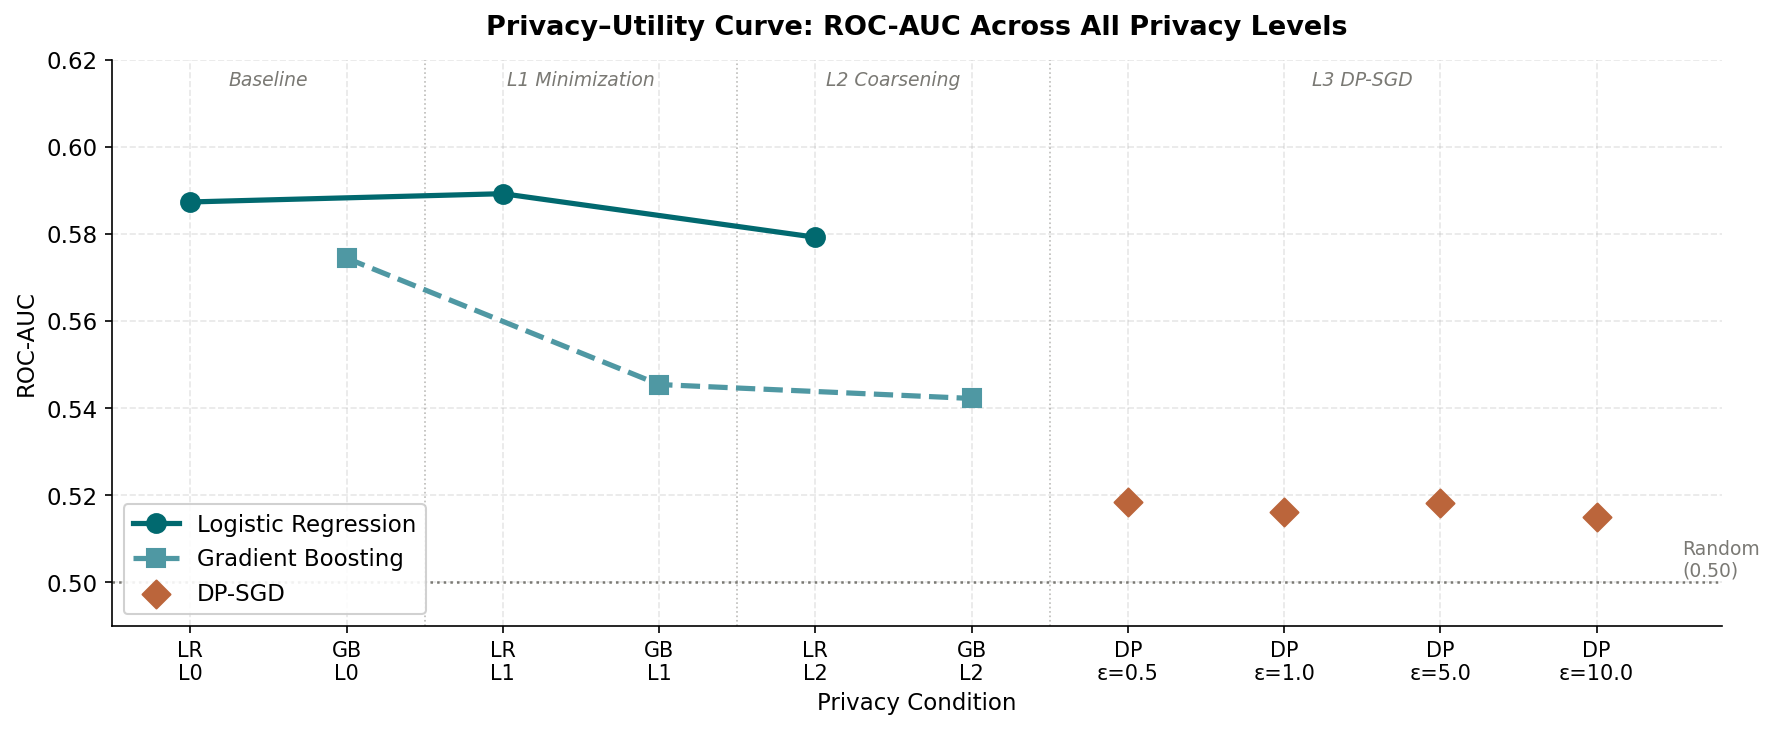

Chart 1 saved.


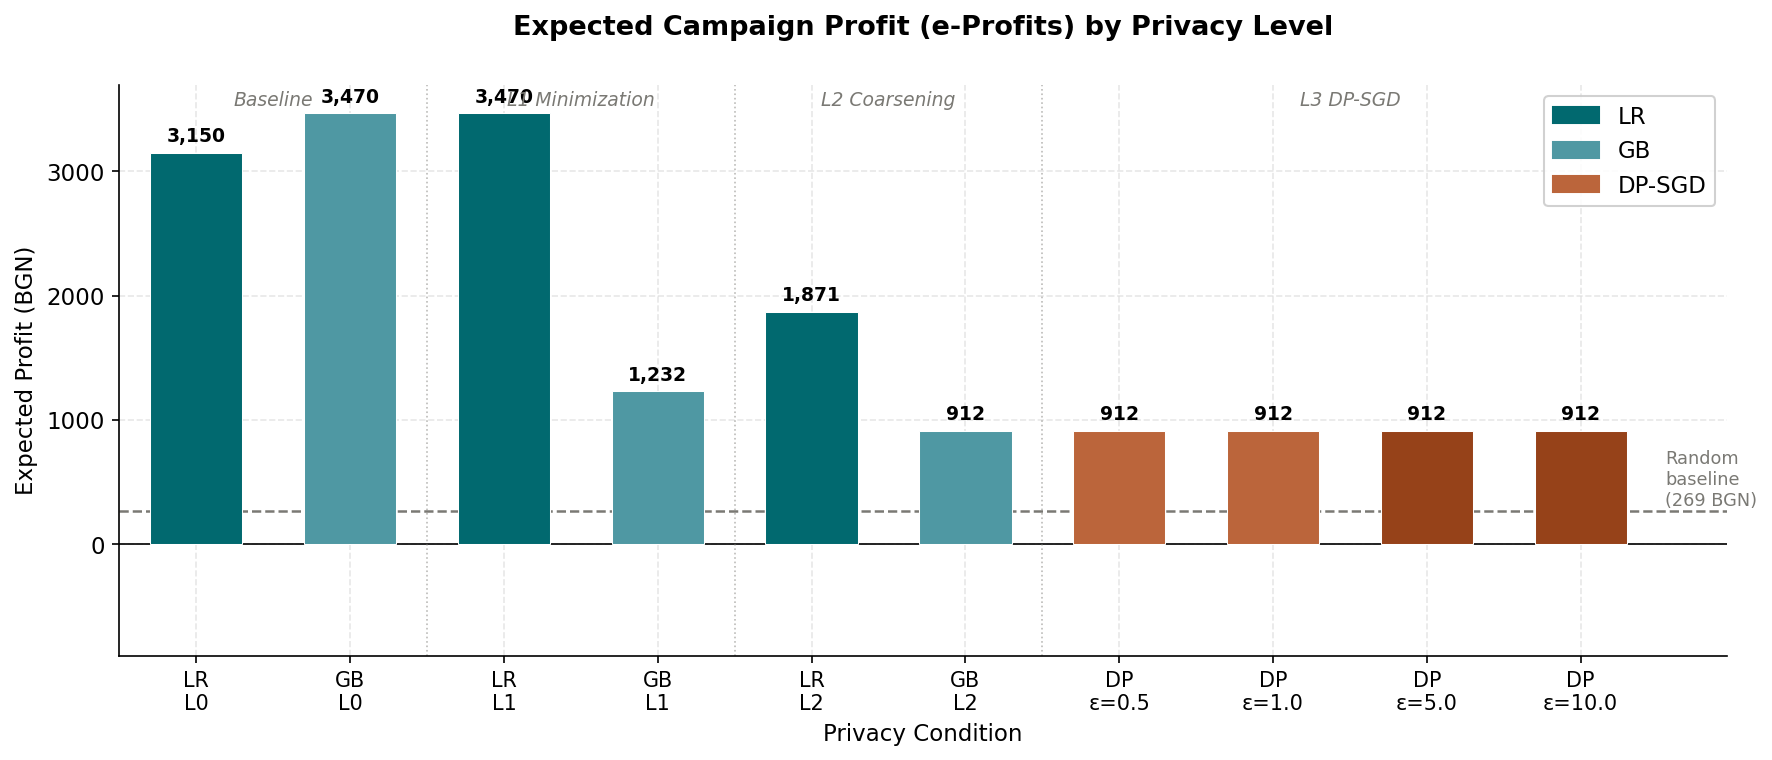

Chart 2 saved.


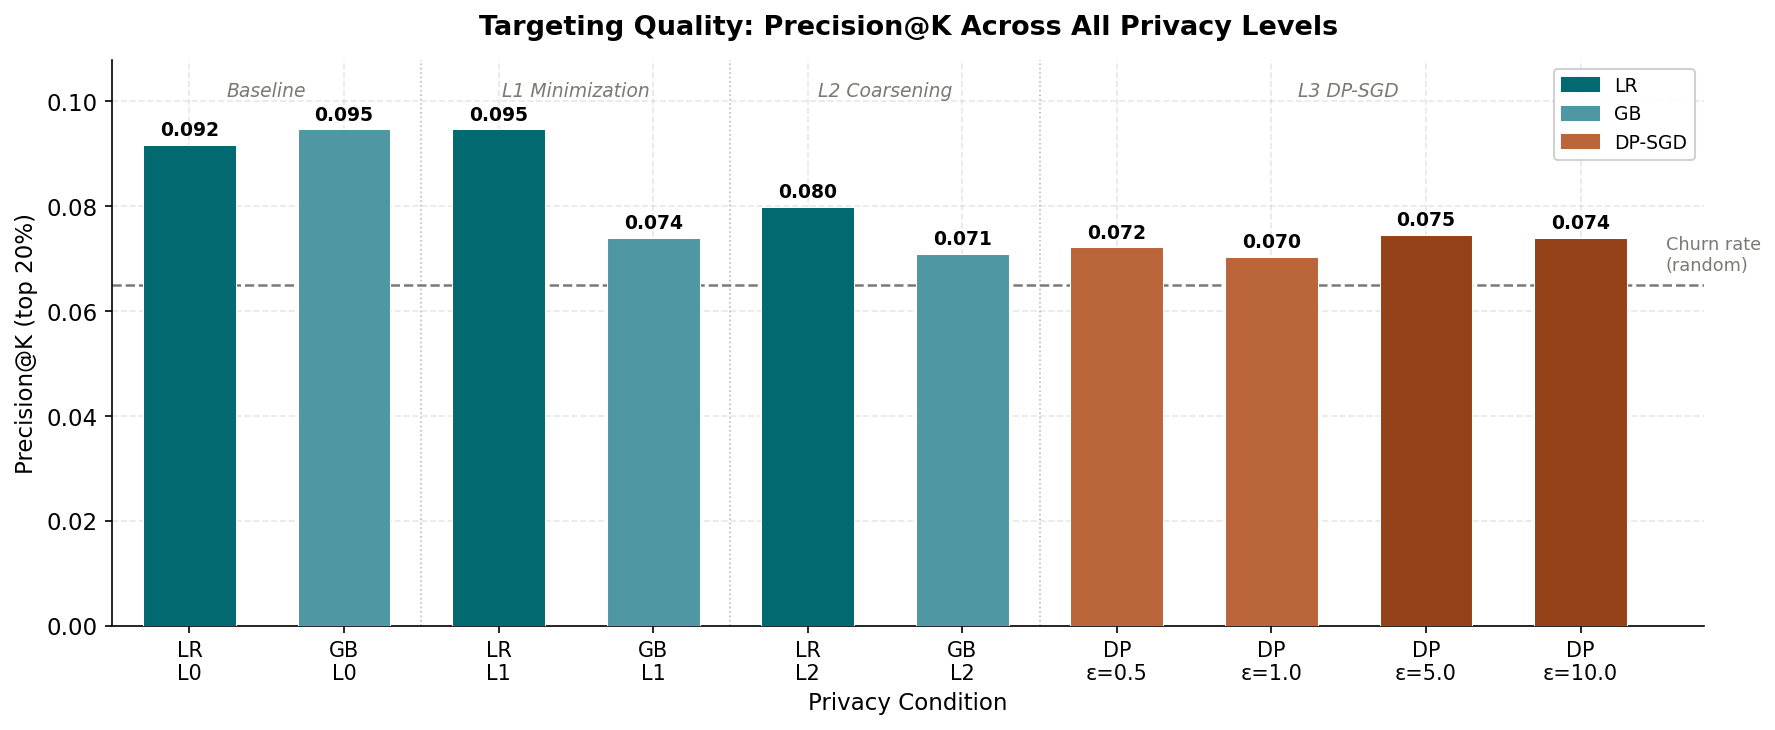

Chart 3 saved.


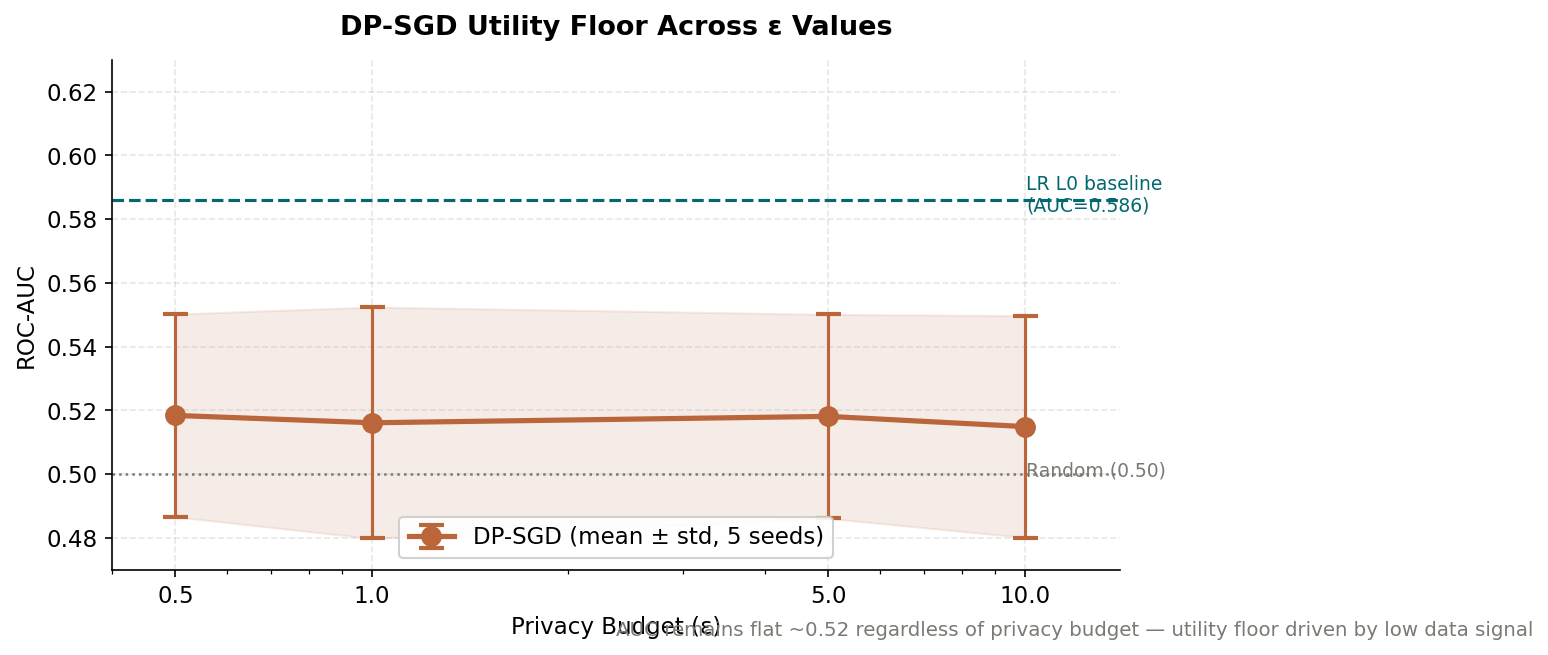

Chart 4 saved.

All 4 charts saved successfully.


In [ ]:

# Script 5: Visualizations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


# ── Shared style ─────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "figure.dpi": 150,
})

TEAL   = "#01696f"
STEEL  = "#4f98a3"
ORANGE = "#bb653b"
AMBER  = "#964219"
GRAY   = "#7a7974"
RED    = "#a12c7b"


# ── Shared data ───────────────────────────────────────────────
x_labels = [
    "LR\nL0", "GB\nL0",
    "LR\nL1", "GB\nL1",
    "LR\nL2", "GB\nL2",
    "DP\nε=0.5", "DP\nε=1.0", "DP\nε=5.0", "DP\nε=10.0",
]
x = np.arange(len(x_labels))

auc = [0.5873, 0.5744, 0.5892, 0.5454, 0.5792, 0.5422,
       0.5184, 0.5161, 0.5181, 0.5149]

preck = [0.0917, 0.0947, 0.0947, 0.0740, 0.0799, 0.0710,
         0.0722, 0.0704, 0.0746, 0.0740]

eprofit = [3150.08, 3469.76, 3469.76, 1232.00, 1871.36, 912.32,
           912.32, 912.32, 912.32, 912.32]

bar_colors = [
    TEAL, STEEL,
    TEAL, STEEL,
    TEAL, STEEL,
    ORANGE, ORANGE, AMBER, AMBER,
]


# ============================================================
# CHART 1 — Privacy-Utility Curve (AUC)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot([0, 2, 4], [auc[0], auc[2], auc[4]],
        color=TEAL, marker="o", linewidth=2.5,
        markersize=9, label="Logistic Regression", zorder=3)

ax.plot([1, 3, 5], [auc[1], auc[3], auc[5]],
        color=STEEL, marker="s", linewidth=2.5, linestyle="--",
        markersize=9, label="Gradient Boosting", zorder=3)

ax.scatter([6, 7, 8, 9], auc[6:],
           color=ORANGE, marker="D", s=90,
           label="DP-SGD", zorder=3)

ax.axhline(0.5, color=GRAY, linestyle=":", linewidth=1.2)
ax.text(9.55, 0.5005, "Random\n(0.50)", fontsize=9,
        color=GRAY, va="bottom")

for xpos in [1.5, 3.5, 5.5]:
    ax.axvline(xpos, color=GRAY, linestyle=":", linewidth=0.8, alpha=0.5)

for xpos, label in [(.5, "Baseline"), (2.5, "L1 Minimization"),
                    (4.5, "L2 Coarsening"), (7.5, "L3 DP-SGD")]:
    ax.text(xpos, 0.614, label, ha="center", fontsize=9,
            color=GRAY, style="italic")

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("Privacy Condition")
ax.set_ylim(0.49, 0.62)
ax.set_xlim(-0.5, 9.8)
ax.legend(loc="lower left", framealpha=0.9)
ax.set_title("Privacy–Utility Curve: ROC-AUC Across All Privacy Levels",
             fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("chart1_privacy_utility_auc.png", bbox_inches="tight")
plt.show()
print("Chart 1 saved.")


# ============================================================
# CHART 2 — e-Profits Bar Chart
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5.2))

bars = ax.bar(x, eprofit, color=bar_colors,
              width=0.6, edgecolor="white", linewidth=0.5, zorder=3)

for bar, val in zip(bars, eprofit):
    ypos = val + 55 if val >= 0 else val - 130
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f"{val:,.0f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(268.80, color=GRAY, linestyle="--", linewidth=1.2)
ax.text(9.55, 520, "Random\nbaseline\n(269 BGN)",
        fontsize=8.5, color=GRAY, va="center", ha="left")

for xpos in [1.5, 3.5, 5.5]:
    ax.axvline(xpos, color=GRAY, linestyle=":", linewidth=0.8, alpha=0.5)

for xpos, label in [(.5, "Baseline"), (2.5, "L1 Minimization"),
                    (4.5, "L2 Coarsening"), (7.5, "L3 DP-SGD")]:
    ax.text(xpos, 3650, label, ha="center", va="top", fontsize=9,
            color=GRAY, style="italic")

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel("Expected Profit (BGN)")
ax.set_xlabel("Privacy Condition")
ax.set_ylim(-900, 3700)
ax.set_xlim(-0.5, 9.95)
ax.set_title("Expected Campaign Profit (e-Profits) by Privacy Level",
             fontsize=13, fontweight="bold", pad=24)

ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [
    mpatches.Patch(color=TEAL, label="LR"),
    mpatches.Patch(color=STEEL, label="GB"),
    mpatches.Patch(color=ORANGE, label="DP-SGD"),
]
ax.legend(handles=legend_handles, loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.savefig("chart2_eprofit.png", bbox_inches="tight")
plt.show()
print("Chart 2 saved.")


# ============================================================
# CHART 3 — Precision@K Bar Chart
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(x, preck, color=bar_colors,
              width=0.6, edgecolor="white", linewidth=0.5, zorder=3)

for bar, val in zip(bars, preck):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.001, f"{val:.3f}",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold")

ax.axhline(0.065, color=GRAY, linestyle="--", linewidth=1.2)
ax.text(9.55, 0.067, "Churn rate\n(random)", fontsize=8.5,
        color=GRAY, va="bottom")

for xpos in [1.5, 3.5, 5.5]:
    ax.axvline(xpos, color=GRAY, linestyle=":", linewidth=0.8, alpha=0.5)

for xpos, label in [(.5, "Baseline"), (2.5, "L1 Minimization"),
                    (4.5, "L2 Coarsening"), (7.5, "L3 DP-SGD")]:
    ax.text(xpos, 0.101, label, ha="center", fontsize=9,
            color=GRAY, style="italic")

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel("Precision@K (top 20%)")
ax.set_xlabel("Privacy Condition")
ax.set_ylim(0, 0.108)
ax.set_xlim(-0.5, 9.8)
ax.set_title("Targeting Quality: Precision@K Across All Privacy Levels",
             fontsize=13, fontweight="bold", pad=12)

legend_handles = [
    mpatches.Patch(color=TEAL,   label="LR"),
    mpatches.Patch(color=STEEL,  label="GB"),
    mpatches.Patch(color=ORANGE, label="DP-SGD"),
]
ax.legend(handles=legend_handles, loc="upper right", framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig("chart3_precision_at_k.png", bbox_inches="tight")
plt.show()
print("Chart 3 saved.")


# ============================================================
# CHART 4 — DP-SGD Utility Floor (UPDATED values)
# ============================================================

# UPDATED: means and stds from new screenshot
dp_eps   = [0.5, 1.0, 5.0, 10.0]
dp_auc_m = [0.5184, 0.5161, 0.5181, 0.5149]
dp_auc_s = [0.0318, 0.0363, 0.0320, 0.0348]

fig, ax = plt.subplots(figsize=(8, 5))
fig.subplots_adjust(left=0.12, right=0.96, top=0.88, bottom=0.20)

ax.errorbar(dp_eps, dp_auc_m, yerr=dp_auc_s,
            fmt="o-", color=ORANGE, linewidth=2.5,
            markersize=9, capsize=6, capthick=2,
            elinewidth=1.5, label="DP-SGD (mean ± std, 5 seeds)",
            zorder=3)

dp_auc_upper = [m + s for m, s in zip(dp_auc_m, dp_auc_s)]
dp_auc_lower = [m - s for m, s in zip(dp_auc_m, dp_auc_s)]
ax.fill_between(dp_eps, dp_auc_lower, dp_auc_upper,
                alpha=0.12, color=ORANGE)

ax.axhline(0.5860, color=TEAL, linestyle="--", linewidth=1.5)
ax.text(10.05, 0.5875, "LR L0 baseline\n(AUC=0.586)",
        fontsize=9, color=TEAL, va="center")

ax.axhline(0.5, color=GRAY, linestyle=":", linewidth=1.2)
ax.text(10.05, 0.501, "Random (0.50)",
        fontsize=9, color=GRAY, va="center")

ax.set_xscale("log")
ax.set_xticks(dp_eps)
ax.set_xticklabels([str(e) for e in dp_eps], fontsize=11)
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("Privacy Budget (ε)")
ax.set_ylim(0.47, 0.63)
ax.set_xlim(0.4, 14)
ax.legend(loc="lower center", framealpha=0.9)
ax.set_title("DP-SGD Utility Floor Across ε Values",
             fontsize=13, fontweight="bold", pad=12)
ax.text(0.5, -0.13,
        "AUC remains flat ~0.52 regardless of privacy budget — utility floor driven by low data signal",
        transform=ax.transAxes, fontsize=9.5,
        color=GRAY, ha="left")

plt.savefig("chart4_dpsgd_floor_fixed.png", dpi=150)
plt.show()
print("Chart 4 saved.")
print("\nAll 4 charts saved successfully.")